Code for Experiment 2
----------------------

This notebook contains the python code used to analyze the data collected during Experiment 2 of the paper "Building Compressed Causal Models of the World." It requires that R also be installed on your computer in order to run mixed ANOVAs. 

In [1]:
#Import all required packages.

import os
os.environ['R_HOME']='/Library/Frameworks/R.framework/Resources' #The home for R on your computer may differ. 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from scipy.stats import entropy
import statsmodels.formula.api as smf
import rpy2.robjects as ro
import rpy2.robjects.packages as rpackages
from rpy2.robjects import pandas2ri, StrVector
from rpy2.robjects.conversion import localconverter

The following block of code imports and cleans the data in the file 'study_2_data.csv'. Ensure that it is saved to the same folder as your notebook.

In [2]:
#Import data and remove labels. 
data = pd.read_csv('study_2_data.csv')
data=data.drop(labels=0,axis=0) 
data=data.drop(labels=1,axis=0)

#Remove all data from participants who failed comprehension checks.
inclusions = []
for i in range(2,len(data)):
    if data.D_CompCheck[i] == 'Drol' or data.B_CompCheck[i] == 'Bricofly' or data.C_CompCheck[i] == 'Chapagite':
        inclusions = np.append(inclusions,[i])

exclusions = [x for x in np.arange(2,len(data)) if x not in inclusions]

data=data.drop(labels=exclusions,axis=0)

#Remove all data from participants who rated any of the poor causal claims positively. 
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropCompBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropHighBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropLowBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropCompBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropHighBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropLowBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropCompBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropHighBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_PropLowBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabCompBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabHighBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabLowBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabCompBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabHighBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabLowBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabCompBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabHighBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.B_StabLowBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropCompBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropHighBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropLowBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropCompBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropHighBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropLowBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropCompBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropHighBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_PropLowBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabCompBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabHighBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabLowBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabCompBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabHighBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabLowBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabCompBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabHighBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.C_StabLowBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropCompBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropHighBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropLowBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropCompBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropHighBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropLowBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropCompBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropHighBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_PropLowBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabCompBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabHighBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabLowBad55_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabCompBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabHighBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabLowBad85_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabCompBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabHighBad98_1 != s]
for i in range(0,4):
    s = str(i)
    data = data[data.D_StabLowBad98_1 != s]
data = data.reset_index()


The following block of code defines the loss function.

In [3]:
def loss(x):
    conditional_noncomp1 = [.01,.99]
    conditional_noncomp2 = [.01,.99]
    conditional_noncomp3 = [.55,.45]
    conditional_noncomp4 = [x,1-x]
    conditional_comp1 = [.01,.99]
    conditional_comp2 = [(.55+x)/2,1-(.55+x)/2]
    marginal = [.01*.5+.55*.25+x*.25,1-(.01*.5+.55*.25+x*.25)]
    cmi_noncomp = .25*entropy(conditional_noncomp1,marginal,2) + .25*entropy(conditional_noncomp2,marginal,2) + .25*entropy(conditional_noncomp3,marginal,2) + .25*entropy(conditional_noncomp4,marginal,2)
    cmi_comp = .5*entropy(conditional_comp1,marginal,2) + .5*entropy(conditional_comp2,marginal,2)
    return cmi_noncomp - cmi_comp

The following block constructs arrays whose values denote:

1. The vignette shown to each participant (vignette)
2. The information loss inherent in choosing a compressed over a non-compressed causal representation in the vignette shown to each participant (loss_vals)
3. Whether the participant was shown a vignette in which compression involved coarsening a causal variable or eliding a background variable (mode).
4. The participant's evaluation of the causal claim Compressed (comp_eval).
5. The participant's evaluation of the causal claim High (high_eval).
6. The participant's evaluation of the causal claim Low (low_eval).
7. The difference between the participant's evaluation of the causal claim Compressed and the causal claim High (comp_high_diff).
8. The difference between the participant's evaluation of the causal claim Compressed and the uniform avgerage of the participant's evaluation of the claims High and Low (comp_avg_diff).
8. The difference between the evaluation of the causal claim High and the uniform avgerage of the participant's evaluation of the causal claim Low (high_low_diff).

In [4]:
vignette = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Bricofly':
        vignette = np.append(vignette,[-1])
    if data.Vignette[i] == 'Chapagite':
        vignette = np.append(vignette,[0])
    if data.Vignette[i] == 'Drol':
        vignette = np.append(vignette,[1])
        
loss_vals = []
for i in range(0,len(data)):
    if data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Stab_No_Loss':
        loss_vals = np.append(loss_vals,[loss(.55)])
    if data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Stab_Loss_1':
        loss_vals = np.append(loss_vals,[loss(.85)])
    if data.Group[i] == 'Prop_Loss_2' or data.Group[i] == 'Stab_Loss_2':
        loss_vals = np.append(loss_vals,[loss(.98)])
        
mode = []
for i in range(0,len(data)):
    if data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Prop_Loss_2':
        mode = np.append(mode,[-1])
    if data.Group[i] == 'Stab_No_Loss' or data.Group[i] == 'Stab_Loss_1' or data.Group[i] == 'Stab_Loss_2':
        mode = np.append(mode,[1])
        
comp_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Bricofly':
        if data.Group[i] == 'Prop_No_Loss':
            comp_eval = np.append(comp_eval,[int(data.B_PropCompGood55_1[i])])
        if data.Group[i] == 'Stab_No_Loss':
            comp_eval = np.append(comp_eval,[int(data.B_StabCompGood55_1[i])])
        if data.Group[i] == 'Prop_Loss_1':
            comp_eval = np.append(comp_eval,[int(data.B_PropCompGood85_1[i])])
        if data.Group[i] == 'Stab_Loss_1':
            comp_eval = np.append(comp_eval,[int(data.B_StabCompGood85_1[i])])
        if data.Group[i] == 'Prop_Loss_2':
            comp_eval = np.append(comp_eval,[int(data.B_PropCompGood98_1[i])])
        if data.Group[i] == 'Stab_Loss_2':
            comp_eval = np.append(comp_eval,[int(data.B_StabCompGood98_1[i])])
    if data.Vignette[i] == 'Chapagite':
        if data.Group[i] == 'Prop_No_Loss':
            comp_eval = np.append(comp_eval,[int(data.C_PropCompGood55_1[i])])
        if data.Group[i] == 'Stab_No_Loss':
            comp_eval = np.append(comp_eval,[int(data.C_StabCompGood55_1[i])])
        if data.Group[i] == 'Prop_Loss_1':
            comp_eval = np.append(comp_eval,[int(data.C_PropCompGood85_1[i])])
        if data.Group[i] == 'Stab_Loss_1':
            comp_eval = np.append(comp_eval,[int(data.C_StabCompGood85_1[i])])
        if data.Group[i] == 'Prop_Loss_2':
            comp_eval = np.append(comp_eval,[int(data.C_PropCompGood98_1[i])])
        if data.Group[i] == 'Stab_Loss_2':
            comp_eval = np.append(comp_eval,[int(data.C_StabCompGood98_1[i])])
    if data.Vignette[i] == 'Drol':
        if data.Group[i] == 'Prop_No_Loss':
            comp_eval = np.append(comp_eval,[int(data.D_PropCompGood55_1[i])])
        if data.Group[i] == 'Stab_No_Loss':
            comp_eval = np.append(comp_eval,[int(data.D_StabCompGood55_1[i])])
        if data.Group[i] == 'Prop_Loss_1':
            comp_eval = np.append(comp_eval,[int(data.D_PropCompGood85_1[i])])
        if data.Group[i] == 'Stab_Loss_1':
            comp_eval = np.append(comp_eval,[int(data.D_StabCompGood85_1[i])])
        if data.Group[i] == 'Prop_Loss_2':
            comp_eval = np.append(comp_eval,[int(data.D_PropCompGood98_1[i])])
        if data.Group[i] == 'Stab_Loss_2':
            comp_eval = np.append(comp_eval,[int(data.D_StabCompGood98_1[i])])

            
high_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Bricofly':
        if data.Group[i] == 'Prop_No_Loss':
            high_eval = np.append(high_eval,[int(data.B_PropHighGood55_1[i])])
        if data.Group[i] == 'Stab_No_Loss':
            high_eval = np.append(high_eval,[int(data.B_StabHighGood55_1[i])])
        if data.Group[i] == 'Prop_Loss_1': 
            high_eval = np.append(high_eval,[int(data.B_PropHighGood85_1[i])])
        if data.Group[i] == 'Stab_Loss_1':
            high_eval = np.append(high_eval,[int(data.B_StabHighGood85_1[i])])
        if data.Group[i] == 'Prop_Loss_2':
            high_eval = np.append(high_eval,[int(data.B_PropHighGood98_1[i])])
        if data.Group[i] == 'Stab_Loss_2':
            high_eval = np.append(high_eval,[int(data.B_StabHighGood98_1[i])])
    if data.Vignette[i] == 'Chapagite':
        if data.Group[i] == 'Prop_No_Loss':
            high_eval = np.append(high_eval,[int(data.C_PropHighGood55_1[i])])
        if data.Group[i] == 'Stab_No_Loss':
            high_eval = np.append(high_eval,[int(data.C_StabHighGood55_1[i])])
        if data.Group[i] == 'Prop_Loss_1':
            high_eval = np.append(high_eval,[int(data.C_PropHighGood85_1[i])])
        if data.Group[i] == 'Stab_Loss_1':
            high_eval = np.append(high_eval,[int(data.C_StabHighGood85_1[i])])
        if data.Group[i] == 'Prop_Loss_2':
            high_eval = np.append(high_eval,[int(data.C_PropHighGood98_1[i])])
        if data.Group[i] == 'Stab_Loss_2':
            high_eval = np.append(high_eval,[int(data.C_StabHighGood98_1[i])])
    if data.Vignette[i] == 'Drol':
        if data.Group[i] == 'Prop_No_Loss':
            high_eval = np.append(high_eval,[int(data.D_PropHighGood55_1[i])])
        if data.Group[i] == 'Stab_No_Loss':
            high_eval = np.append(high_eval,[int(data.D_StabHighGood55_1[i])])
        if data.Group[i] == 'Prop_Loss_1':
            high_eval = np.append(high_eval,[int(data.D_PropHighGood85_1[i])])
        if data.Group[i] == 'Stab_Loss_1':
            high_eval = np.append(high_eval,[int(data.D_StabHighGood85_1[i])])
        if data.Group[i] == 'Prop_Loss_2':
            high_eval = np.append(high_eval,[int(data.D_PropHighGood98_1[i])])
        if data.Group[i] == 'Stab_Loss_2':
            high_eval = np.append(high_eval,[int(data.D_StabHighGood98_1[i])])

low_eval = []
for i in range(0,len(data)):
    if data.Vignette[i] == 'Bricofly':
        if data.Group[i] == 'Prop_No_Loss':
            low_eval = np.append(low_eval,[int(data.B_PropLowGood55_1[i])])
        if data.Group[i] == 'Stab_No_Loss':
            low_eval = np.append(low_eval,[int(data.B_StabLowGood55_1[i])])
        if data.Group[i] == 'Prop_Loss_1': 
            low_eval = np.append(low_eval,[int(data.B_PropLowGood85_1[i])])
        if data.Group[i] == 'Stab_Loss_1':
            low_eval = np.append(low_eval,[int(data.B_StabLowGood85_1[i])])
        if data.Group[i] == 'Prop_Loss_2':
            low_eval = np.append(low_eval,[int(data.B_PropLowGood98_1[i])])
        if data.Group[i] == 'Stab_Loss_2':
            low_eval = np.append(low_eval,[int(data.B_StabLowGood98_1[i])])
    if data.Vignette[i] == 'Chapagite':
        if data.Group[i] == 'Prop_No_Loss':
            low_eval = np.append(low_eval,[int(data.C_PropLowGood55_1[i])])
        if data.Group[i] == 'Stab_No_Loss':
            low_eval = np.append(low_eval,[int(data.C_StabLowGood55_1[i])])
        if data.Group[i] == 'Prop_Loss_1':
            low_eval = np.append(low_eval,[int(data.C_PropLowGood85_1[i])])
        if data.Group[i] == 'Stab_Loss_1':
            low_eval = np.append(low_eval,[int(data.C_StabLowGood85_1[i])])
        if data.Group[i] == 'Prop_Loss_2':
            low_eval = np.append(low_eval,[int(data.C_PropLowGood98_1[i])])
        if data.Group[i] == 'Stab_Loss_2':
            low_eval = np.append(low_eval,[int(data.C_StabLowGood98_1[i])])
    if data.Vignette[i] == 'Drol':
        if data.Group[i] == 'Prop_No_Loss':
            low_eval = np.append(low_eval,[int(data.D_PropLowGood55_1[i])])
        if data.Group[i] == 'Stab_No_Loss':
            low_eval = np.append(low_eval,[int(data.D_StabLowGood55_1[i])])
        if data.Group[i] == 'Prop_Loss_1':
            low_eval = np.append(low_eval,[int(data.D_PropLowGood85_1[i])])
        if data.Group[i] == 'Stab_Loss_1':
            low_eval = np.append(low_eval,[int(data.D_StabLowGood85_1[i])])
        if data.Group[i] == 'Prop_Loss_2':
            low_eval = np.append(low_eval,[int(data.D_PropLowGood98_1[i])])
        if data.Group[i] == 'Stab_Loss_2':
            low_eval = np.append(low_eval,[int(data.D_StabLowGood98_1[i])])
            


comp_high_diff = comp_eval - high_eval
comp_avg_diff = comp_eval - [.5*high_eval[i]+.5*low_eval[i] for i in range(0,len(data)-2)]
high_low_diff = high_eval - low_eval  
comp_low_diff = comp_eval - low_eval  

The following block regresses the difference between the participant's evaluation of the causal claim Compressed and the causal claim High (the variable COMPRESSED-HIGH in the paper) against the Vignette, Loss, Mode, and all interactions between the three independent variables.

In [5]:
arr = np.hstack((vignette.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),comp_high_diff.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Vignette', 'Mode', 'Loss', 'Comp_High_Diff'])
mod = smf.ols(formula='Comp_High_Diff ~ Vignette*Mode*Loss', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:         Comp_High_Diff   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     18.34
Date:                Tue, 09 Apr 2024   Prob (F-statistic):           1.23e-21
Time:                        00:43:29   Log-Likelihood:                -810.06
No. Observations:                 483   AIC:                             1636.
Df Residuals:                     475   BIC:                             1670.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.4308      0

The following block regresses the difference between the participant's evaluation of the causal claim Compressed and the average of their evaluations of causal claims High and Low (the variable COMPRESSED-AVG(HIGH,LOW) in the paper) against the Vignette, Loss, Mode, and all interactions between the three independent variables.

In [6]:
arr = np.hstack((vignette.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),comp_avg_diff.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Vignette', 'Mode', 'Loss', 'Comp_Avg_Diff'])
mod = smf.ols(formula='Comp_Avg_Diff ~ Vignette*Mode*Loss', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          Comp_Avg_Diff   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     4.631
Date:                Tue, 09 Apr 2024   Prob (F-statistic):           4.98e-05
Time:                        00:43:31   Log-Likelihood:                -763.69
No. Observations:                 483   AIC:                             1543.
Df Residuals:                     475   BIC:                             1577.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.5699      0

The following block regresses the difference between the participant's evaluation of the causal claims High and Low (the variable HIGH-LOW in the paper) against the Vignette, Loss, Mode, and all interactions between the three independent variables.

In [7]:
arr = np.hstack((vignette.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),high_low_diff.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Vignette', 'Mode', 'Loss', 'High_Low_Diff'])
mod = smf.ols(formula='High_Low_Diff ~ Vignette*Mode*Loss', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          High_Low_Diff   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     28.57
Date:                Tue, 09 Apr 2024   Prob (F-statistic):           7.52e-33
Time:                        00:43:33   Log-Likelihood:                -753.58
No. Observations:                 483   AIC:                             1523.
Df Residuals:                     475   BIC:                             1557.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2782      0

The following block regresses COMPRESSED - AVG(HIGH,LOW) against Vignette, Mode of Compression, and the difference in the causal power of Compressed and the average causal power of Hgh and Low.

In [8]:
cp_comp_avg_diff  = []
for i in range(0,len(data)):
    if data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Stab_No_Loss':
        cp_comp_avg_diff = np.append(cp_comp_avg_diff,[.101])
    if data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Stab_Loss_1':
        cp_comp_avg_diff = np.append(cp_comp_avg_diff,[.106])
    if data.Group[i] == 'Prop_Loss_2' or data.Group[i] == 'Stab_Loss_2':
        cp_comp_avg_diff = np.append(cp_comp_avg_diff,[.112])
        
arr = np.hstack((vignette.reshape(-1,1),mode.reshape(-1,1),cp_comp_avg_diff.reshape(-1,1),comp_avg_diff.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Vignette', 'Mode', 'CP_Diff', 'Comp_Avg_Diff'])
mod = smf.ols(formula='Comp_Avg_Diff ~ Vignette*Mode*CP_Diff', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          Comp_Avg_Diff   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     4.802
Date:                Tue, 09 Apr 2024   Prob (F-statistic):           3.08e-05
Time:                        00:43:35   Log-Likelihood:                -763.12
No. Observations:                 483   AIC:                             1542.
Df Residuals:                     475   BIC:                             1576.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 7.25

The following three blocks regress the participant's evaluations of Comp, High, and Low, respectively,  against the Vignette, Loss, Mode, and all interactions between the three independent variables. These regressions generate the statistics reported in the Supplemental Materials.

In [9]:
arr = np.hstack((vignette.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),comp_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Vignette', 'Mode', 'Loss', 'Comp_Eval'])
mod = smf.ols(formula='Comp_Eval ~ Vignette + Mode + Loss + Vignette:Mode + Vignette:Loss + Mode:Loss + Vignette:Mode:Loss', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              Comp_Eval   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.8498
Date:                Tue, 09 Apr 2024   Prob (F-statistic):              0.546
Time:                        00:43:38   Log-Likelihood:                -805.73
No. Observations:                 483   AIC:                             1627.
Df Residuals:                     475   BIC:                             1661.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.7077      0

In [10]:
arr = np.hstack((vignette.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),high_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Vignette', 'Mode', 'Loss', 'High_Eval'])
mod = smf.ols(formula='High_Eval ~ Vignette + Mode + Loss + Vignette:Mode + Vignette:Loss + Mode:Loss + Vignette:Mode:Loss', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              High_Eval   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     19.95
Date:                Tue, 09 Apr 2024   Prob (F-statistic):           1.77e-23
Time:                        00:43:40   Log-Likelihood:                -798.12
No. Observations:                 483   AIC:                             1612.
Df Residuals:                     475   BIC:                             1646.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.2769      0

In [11]:
arr = np.hstack((vignette.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),low_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Vignette', 'Mode', 'Loss', 'Low_Eval'])
mod = smf.ols(formula='Low_Eval ~ Vignette + Mode + Loss + Vignette:Mode + Vignette:Loss + Mode:Loss + Vignette:Mode:Loss', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               Low_Eval   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.247
Date:                Tue, 09 Apr 2024   Prob (F-statistic):              0.275
Time:                        00:43:40   Log-Likelihood:                -839.18
No. Observations:                 483   AIC:                             1694.
Df Residuals:                     475   BIC:                             1728.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.9987      0

The following block generates the figure showing the main experimental results.

/var/folders/09/dm7f60811cqgm3lr35c86qfw0000gn/T/ipykernel_35771/3023344123.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['0','1','2','3'],fontsize=30)


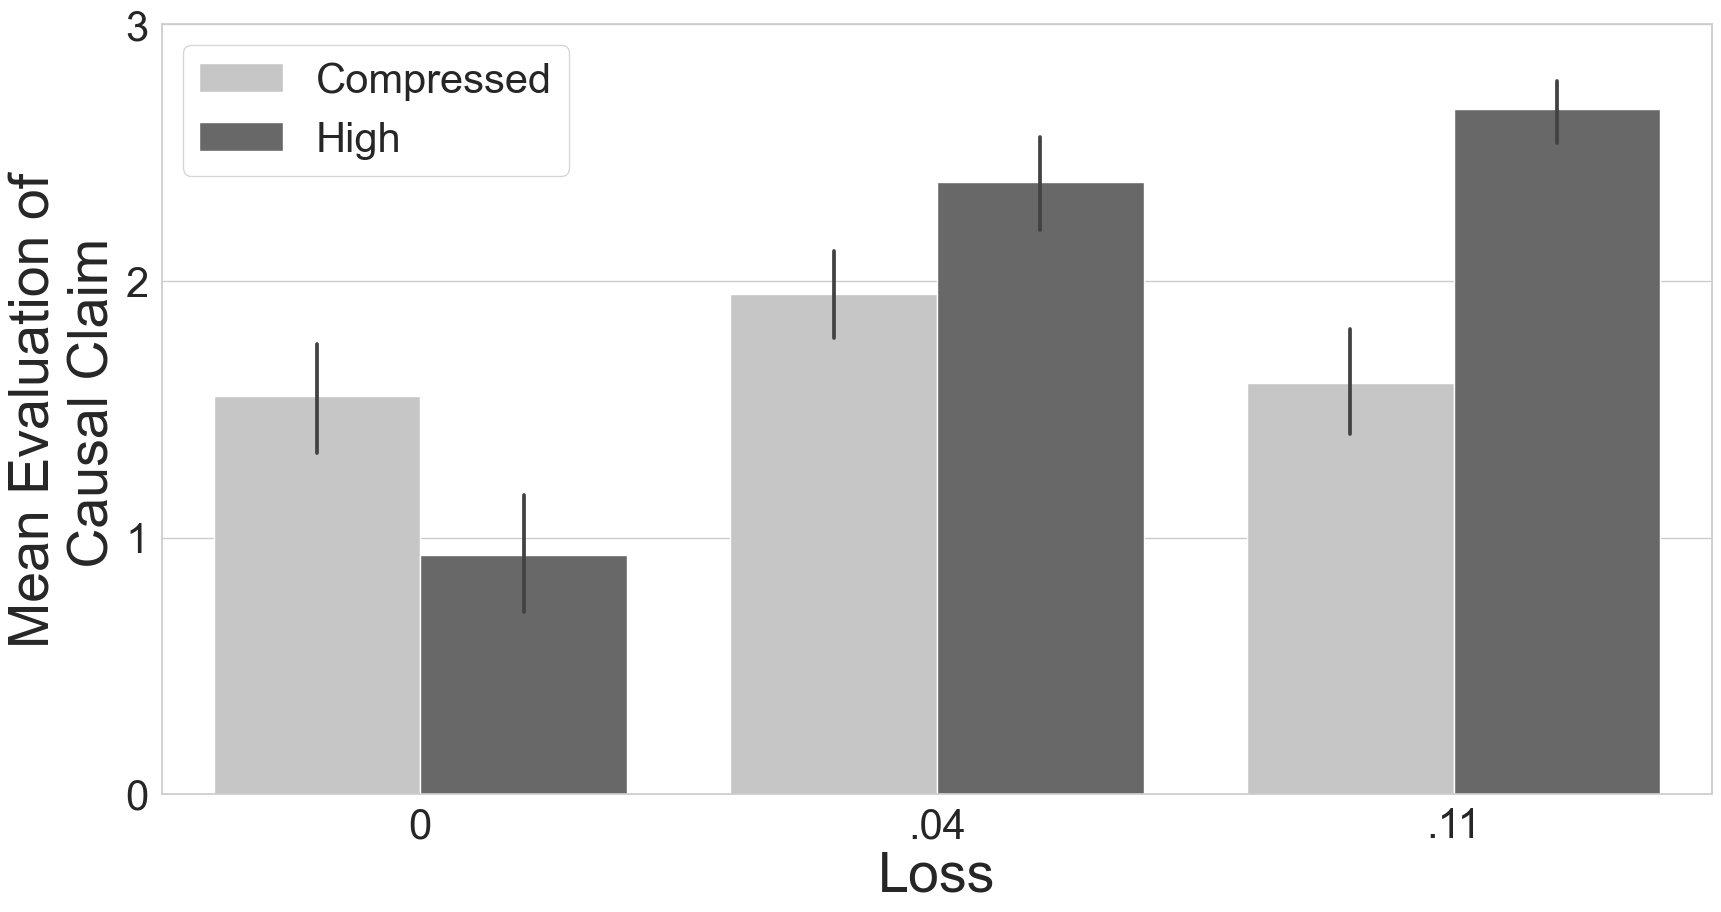

In [12]:
arr = np.hstack((vignette.reshape(-1,1),mode.reshape(-1,1),loss_vals.reshape(-1,1),comp_eval.reshape(-1,1),high_eval.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Vignette', 'Mode', 'Loss', 'Compressed', 'High'])
datamelt = df.melt('Loss', value_vars=['Compressed','High'],var_name='')
sns.set(rc = {'figure.figsize':(20,10)})
sns.set_style('whitegrid')
ax=sns.barplot(x='Loss', y='value', hue='',palette='Greys', data=datamelt)
ax.set_ylabel('Mean Evaluation of\n Causal Claim',fontsize=40)
ax.set_xlabel('Loss',fontsize=40)
ax.set_xticklabels(['0','.04','.11'],fontsize=30)
ax.set_yticklabels(['0','1','2','3'],fontsize=30)
plt.yticks(ticks=[0,1,2,3],fontsize=30)
#ax.set_title('Evaluations of Causal Claims As a Function of Information Loss',fontsize=50)
plt.legend(fontsize=30)
plt.savefig('study2_barplot')

The following two blocks generate the figures comparing mean evaluations of causal claims in both the proportionality and stability settings of the mode of compression variable, as reported in the supplemental materials.

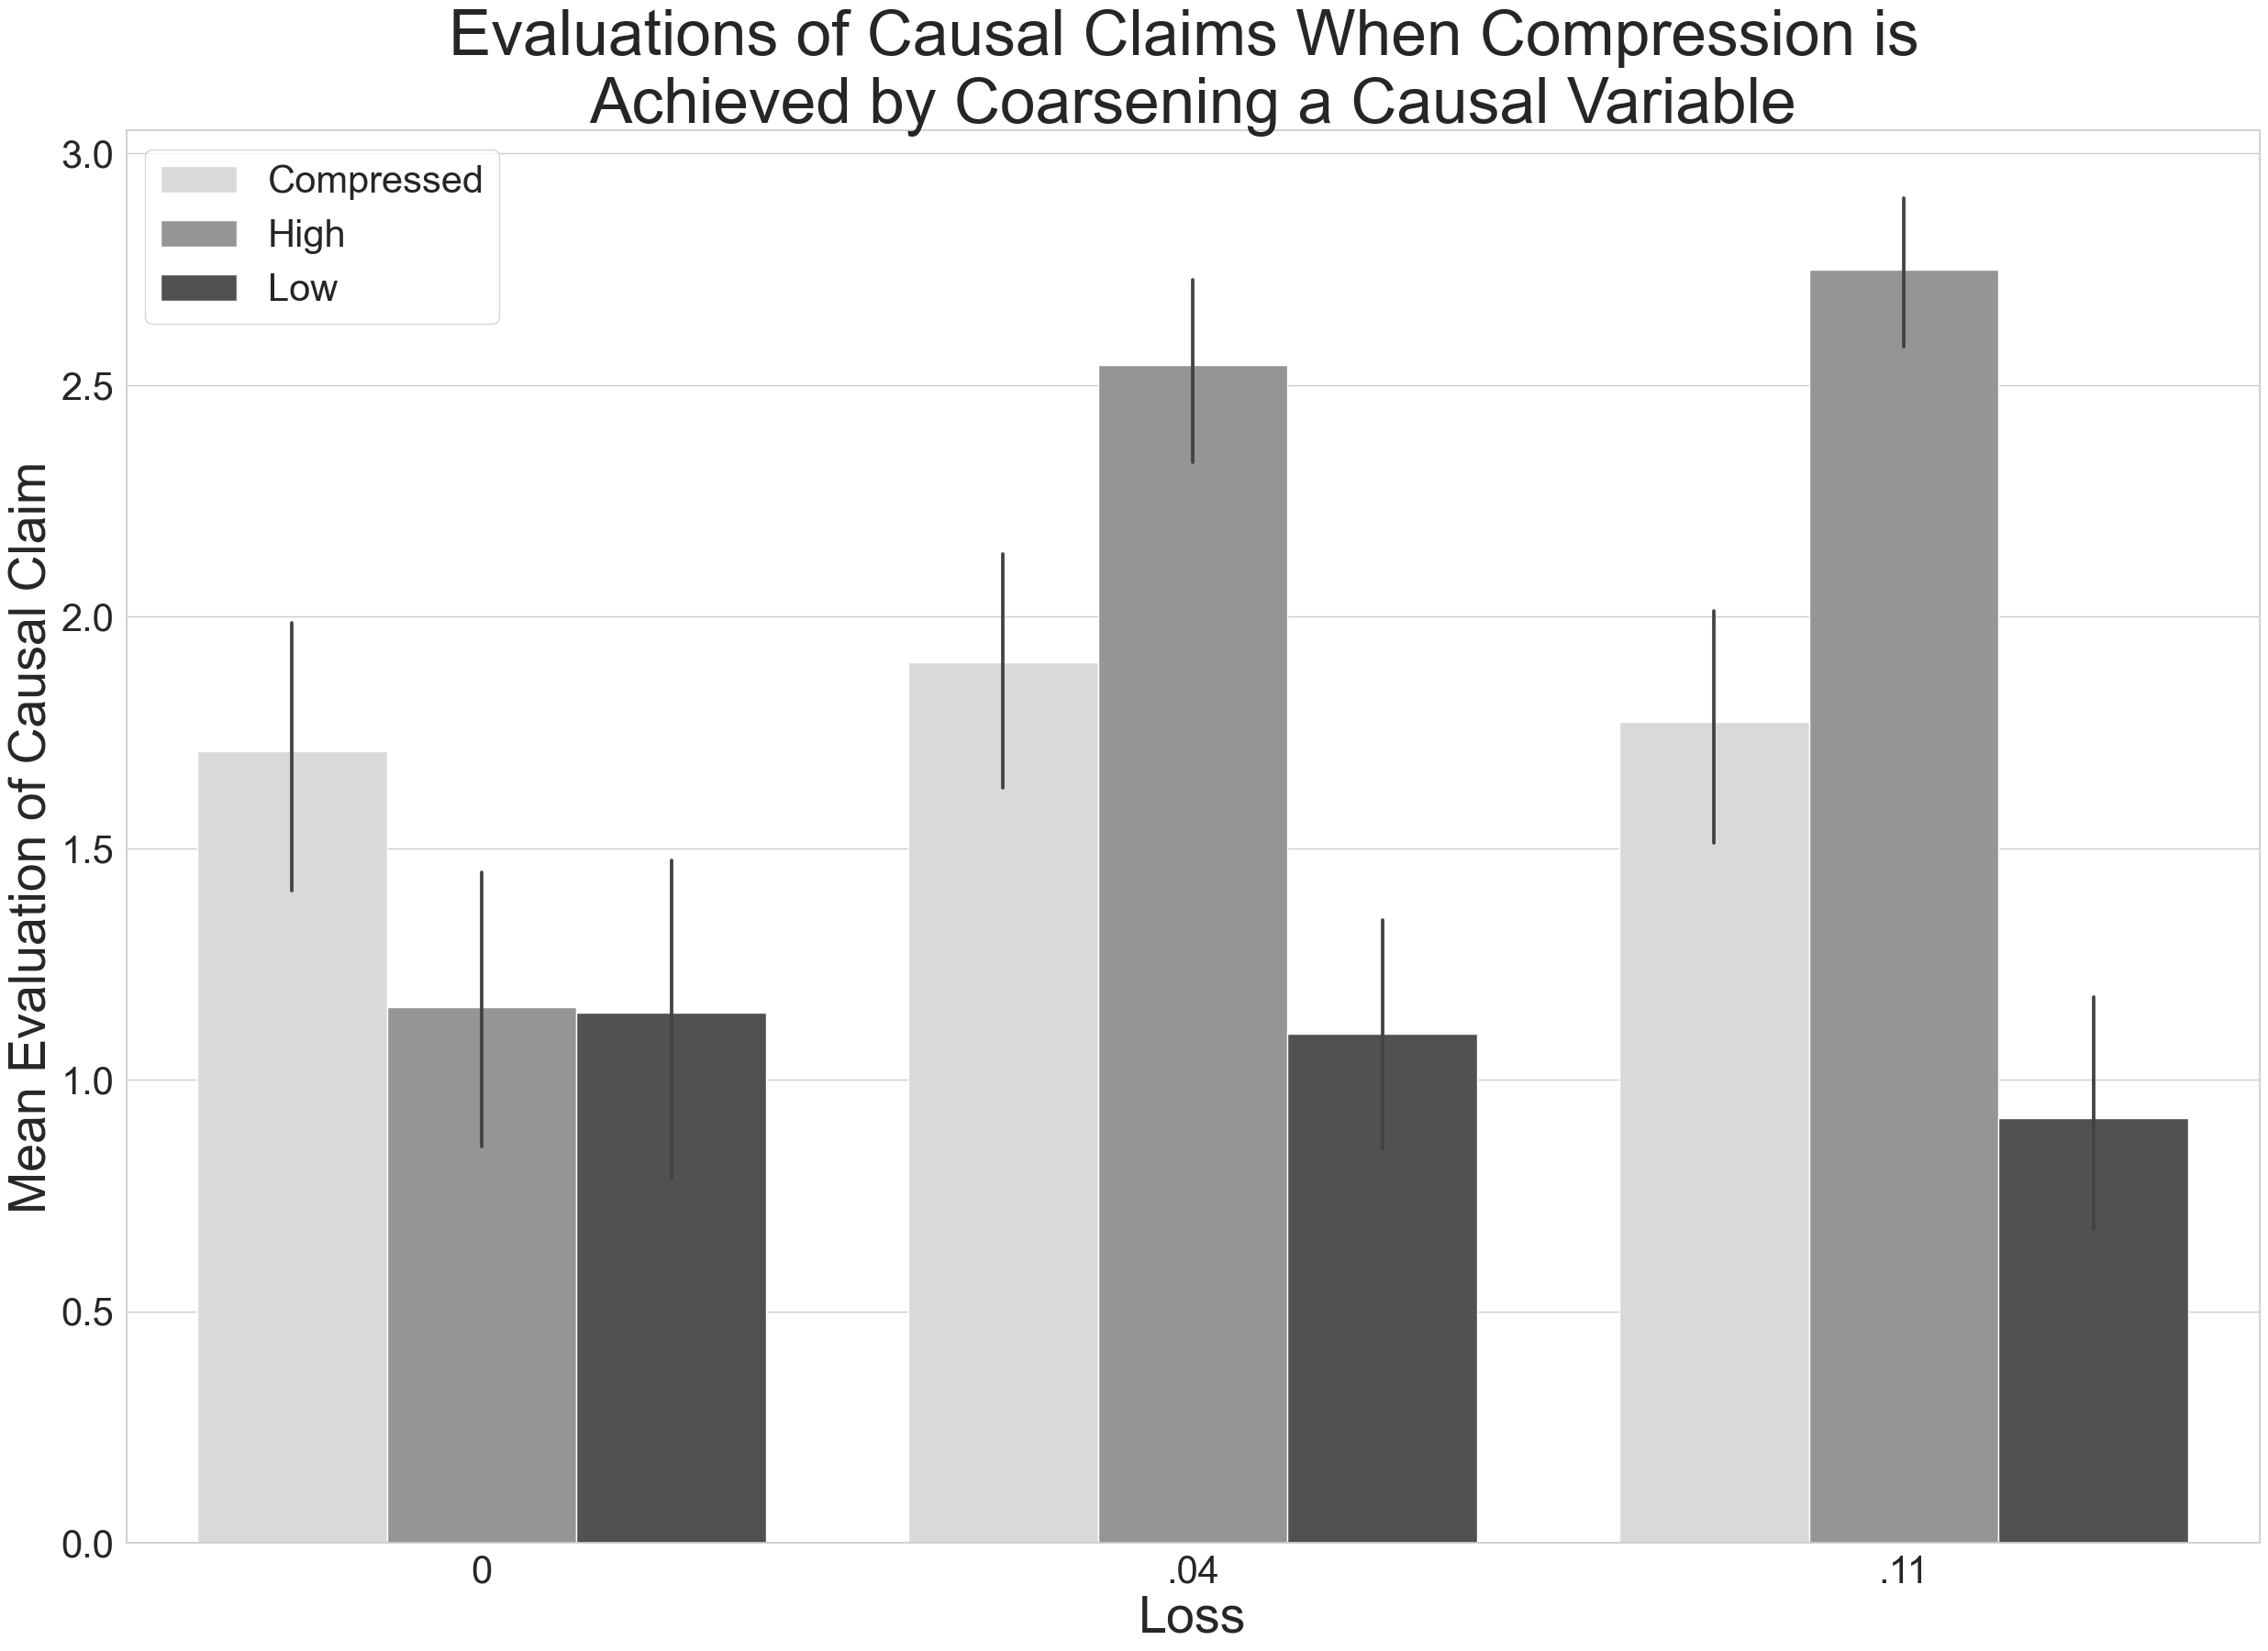

In [16]:
vignette_prop = []
loss_vals_prop = []
comp_eval_prop = []
high_eval_prop = []
low_eval_prop = []

for i in range(0,483):
    if mode[i] == -1:
        vignette_prop = np.append(vignette_prop,[vignette[i]])
        loss_vals_prop = np.append(loss_vals_prop,[loss_vals[i]])
        comp_eval_prop = np.append(comp_eval_prop,[comp_eval[i]])
        high_eval_prop = np.append(high_eval_prop,[high_eval[i]])
        low_eval_prop = np.append(low_eval_prop,[low_eval[i]])

arr = np.hstack((vignette_prop.reshape(-1,1),loss_vals_prop.reshape(-1,1),comp_eval_prop.reshape(-1,1),high_eval_prop.reshape(-1,1),low_eval_prop.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Vignette', 'Loss', 'Compressed', 'High', 'Low'])
datamelt = df.melt('Loss', value_vars=['Compressed','High','Low'],var_name='')
sns.set(rc = {'figure.figsize':(30,20)})
sns.set_style('whitegrid')
ax=sns.barplot(x='Loss', y='value', hue='',palette='Greys', data=datamelt)
ax.set_ylabel('Mean Evaluation of Causal Claim',fontsize=40)
ax.set_xlabel('Loss',fontsize=40)
ax.set_xticklabels(['0','.04','.11'],fontsize=30)
plt.yticks(fontsize=30)
ax.set_title('Evaluations of Causal Claims When Compression is \nAchieved by Coarsening a Causal Variable',fontsize=50)
plt.legend(fontsize=30)
plt.savefig('study2_barplot_prop')

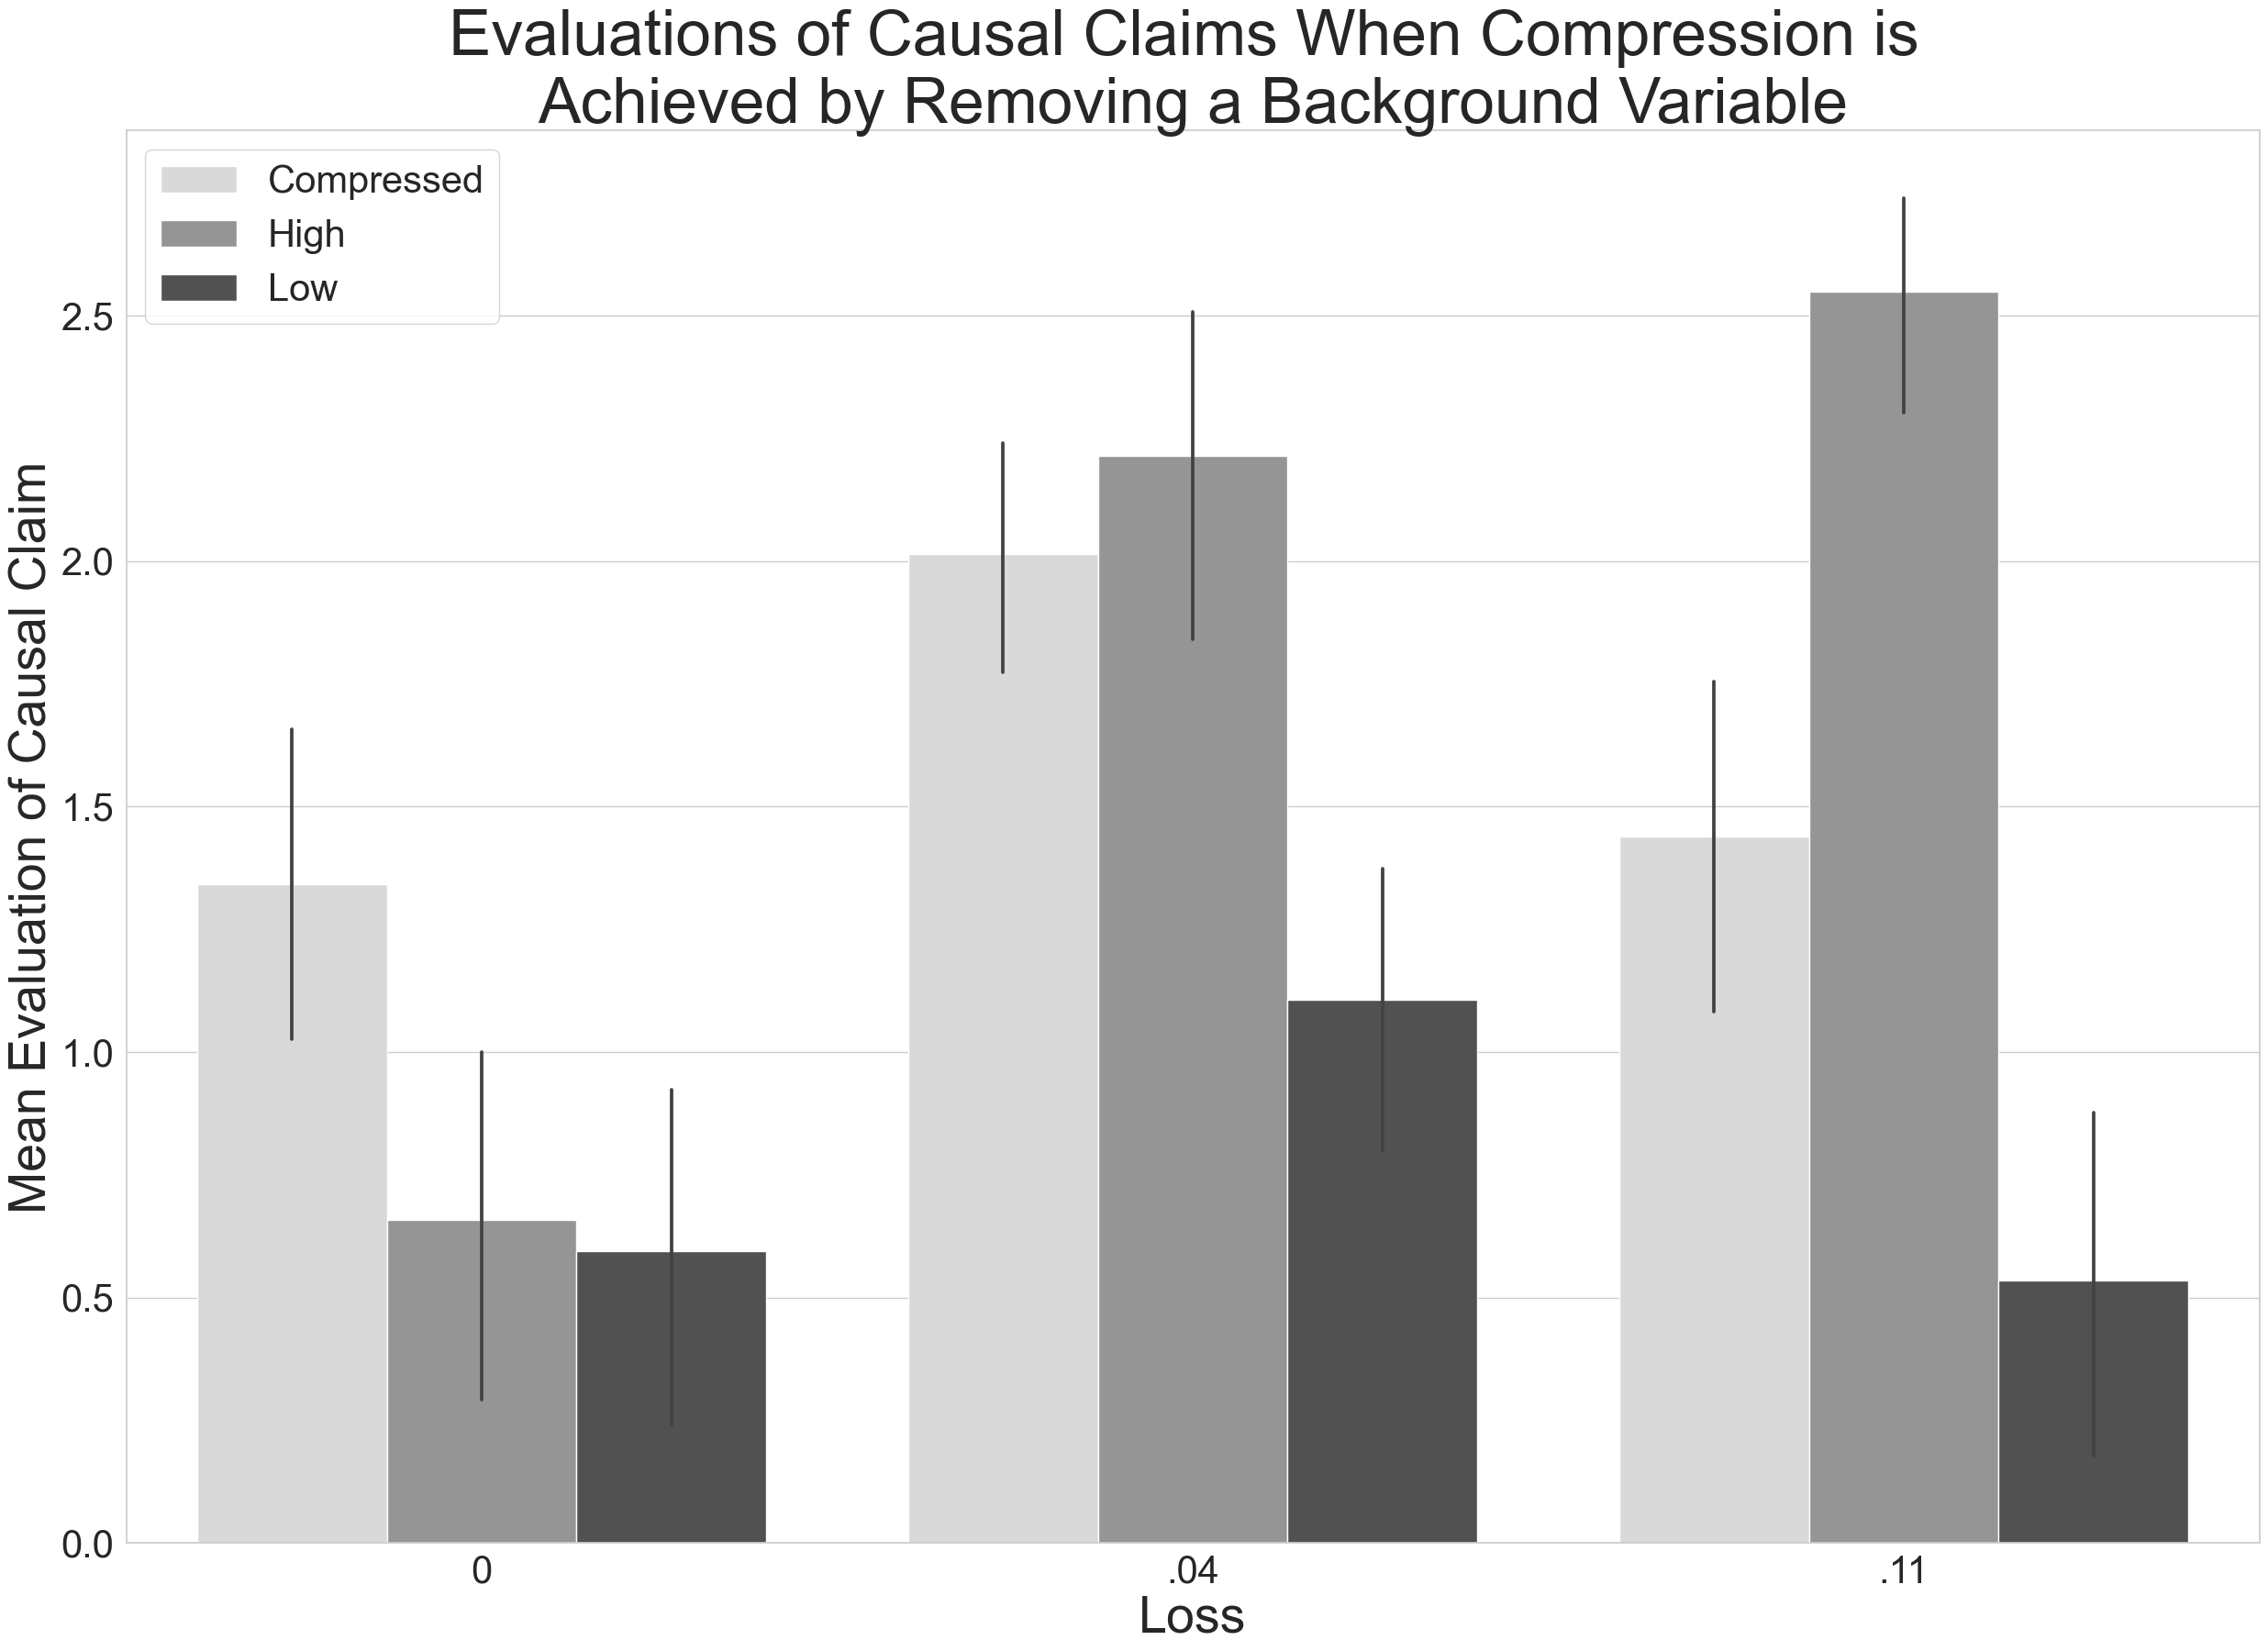

In [31]:
vignette_stab = []
loss_vals_stab = []
comp_eval_stab = []
high_eval_stab = []
low_eval_stab = []

for i in range(0,450):
    if mode[i] == 1:
        vignette_stab = np.append(vignette_stab,[vignette[i]])
        loss_vals_stab = np.append(loss_vals_stab,[loss_vals[i]])
        comp_eval_stab = np.append(comp_eval_stab,[comp_eval[i]])
        high_eval_stab = np.append(high_eval_stab,[high_eval[i]])
        low_eval_stab = np.append(low_eval_stab,[low_eval[i]])

arr = np.hstack((vignette_stab.reshape(-1,1),loss_vals_stab.reshape(-1,1),comp_eval_stab.reshape(-1,1),high_eval_stab.reshape(-1,1),low_eval_stab.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Vignette', 'Loss', 'Compressed', 'High', 'Low'])
datamelt = df.melt('Loss', value_vars=['Compressed','High','Low'],var_name='')
ax=sns.barplot(x='Loss', y='value', hue='',palette='Greys', data=datamelt)
sns.set(rc = {'figure.figsize':(35,20)})
sns.set_style('whitegrid')
ax.set_ylabel('Mean Evaluation of Causal Claim',fontsize=40)
ax.set_xlabel('Loss',fontsize=40)
ax.set_xticklabels(['0','.04','.11'],fontsize=30)
plt.yticks(fontsize=30)
ax.set_title('Evaluations of Causal Claims When Compression is \nAchieved by Removing a Background Variable',fontsize=50)
plt.legend(fontsize=30)
plt.savefig('study2_barplot_stab')

The following block performs the ANOVA analysis for the difference in evaluation between Compressed and High when Loss=0. 

In [13]:
subject_55=[]
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Stab_No_Loss':
        subject_55 = np.append(subject_55,[i,i])

evals_high_55 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Stab_No_Loss':
        evals_high_55 = np.append(evals_high_55,[comp_eval[i],high_eval[i]])
    
    
vignette_for_anova_55 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Stab_No_Loss':
        vignette_for_anova_55 = np.append(vignette_for_anova_55,[vignette[i],vignette[i]])
    
mode_for_anova_55 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Stab_No_Loss':                                                       
        mode_for_anova_55 = np.append(mode_for_anova_55,[mode[i],mode[i]])
    
loss_vals_for_anova_55 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Stab_No_Loss':                                                      
        loss_vals_for_anova_55 = np.append(loss_vals_for_anova_55,[loss_vals[i],loss_vals[i]])
    
diff_type_55 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Stab_No_Loss':
        diff_type_55 = np.append(diff_type_55,[-1,1])

arr = np.hstack((subject_55.reshape(-1,1),vignette_for_anova_55.reshape(-1,1),mode_for_anova_55.reshape(-1,1),loss_vals_for_anova_55.reshape(-1,1),evals_high_55.reshape(-1,1),diff_type_55.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Vignette', 'Mode', 'Loss', 'Eval_High','Diff_Type'])


packageNames = ("afex", "emmeans")
utils = rpackages.importr("utils")
utils.chooseCRANmirror(ind=1)

packnames_to_install = [x for x in packageNames if not rpackages.isinstalled(x)]

if len(packnames_to_install) > 0:
    utils.install_packages(StrVector(packnames_to_install))

# convert pandas DF ("tmp") to R data.frame
with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval_High",
    between=["Vignette", "Mode"],
    within="Diff_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval_High ~ Vignette * Mode + Error(Subject/(Diff_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval_High
                   Effect     df  MSE         F   ges p.value
1                Vignette 2, 152 3.37      0.45  .005    .637
2                    Mode 1, 152 3.37    3.28 +  .017    .072
3           Vignette:Mode 2, 152 3.37      0.08 <.001    .920
4               Diff_Type 1, 152 0.91 32.91 ***  .044   <.001
5      Vignette:Diff_Type 2, 152 0.91      0.00 <.001    .998
6          Mode:Diff_Type 1, 152 0.91      0.41 <.001    .524
7 Vignette:Mode:Diff_Type 2, 152 0.91      0.32 <.001    .727
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs the ANOVA analysis for the difference in evaluation between Compressed and Low when Loss=0. 

In [14]:
evals_low_55 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Stab_No_Loss':
        evals_low_55 = np.append(evals_low_55,[comp_eval[i],low_eval[i]])
        
        
arr = np.hstack((subject_55.reshape(-1,1),vignette_for_anova_55.reshape(-1,1),mode_for_anova_55.reshape(-1,1),loss_vals_for_anova_55.reshape(-1,1),evals_low_55.reshape(-1,1),diff_type_55.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Vignette', 'Mode', 'Loss', 'Eval_Low','Diff_Type'])
        
# convert pandas DF ("tmp") to R data.frame
with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval_Low",
    between=["Vignette", "Mode"],
    within="Diff_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model) 

R[write to console]: Formula send to aov_car: Eval_Low ~ Vignette * Mode + Error(Subject/(Diff_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval_Low
                   Effect     df  MSE         F   ges p.value
1                Vignette 2, 152 3.37      0.04 <.001    .963
2                    Mode 1, 152 3.37    3.74 +  .018    .055
3           Vignette:Mode 2, 152 3.37      0.32  .003    .726
4               Diff_Type 1, 152 1.06 32.20 ***  .048   <.001
5      Vignette:Diff_Type 2, 152 1.06      0.85  .003    .430
6          Mode:Diff_Type 1, 152 1.06      0.65  .001    .420
7 Vignette:Mode:Diff_Type 2, 152 1.06      0.99  .003    .372
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs the ANOVA analysis for the difference in evaluation between Compressed and High when Loss=.07

In [15]:
subject_85=[]
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Stab_Loss_1':
        subject_85 = np.append(subject_85,[i,i])

evals_85 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Stab_Loss_1':
        evals_85 = np.append(evals_85,[comp_eval[i],high_eval[i]])
    
vignette_for_anova_85 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Stab_Loss_1':
        vignette_for_anova_85 = np.append(vignette_for_anova_85,[vignette[i],vignette[i]])
    
mode_for_anova_85 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Stab_Loss_1':                                                       
        mode_for_anova_85 = np.append(mode_for_anova_85,[mode[i],mode[i]])
    
loss_vals_for_anova_85 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Stab_Loss_1':                                                     
        loss_vals_for_anova_85 = np.append(loss_vals_for_anova_85,[loss_vals[i],loss_vals[i]])
    
diff_type_85 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Stab_Loss_1':
        diff_type_85 = np.append(diff_type_85,[-1,1])

arr = np.hstack((subject_85.reshape(-1,1),vignette_for_anova_85.reshape(-1,1),mode_for_anova_85.reshape(-1,1),loss_vals_for_anova_85.reshape(-1,1),evals_85.reshape(-1,1),diff_type_85.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Vignette', 'Mode', 'Loss', 'Eval','Diff_Type'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette", "Mode"],
    within="Diff_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode + Error(Subject/(Diff_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval
                   Effect     df  MSE         F   ges p.value
1                Vignette 2, 155 1.89      0.86  .008    .424
2                    Mode 1, 155 1.89      0.23  .001    .635
3           Vignette:Mode 2, 155 1.89    3.26 *  .029    .041
4               Diff_Type 1, 155 0.76 20.12 ***  .036   <.001
5      Vignette:Diff_Type 2, 155 0.76      0.22 <.001    .805
6          Mode:Diff_Type 1, 155 0.76    4.87 *  .009    .029
7 Vignette:Mode:Diff_Type 2, 155 0.76      0.14 <.001    .868
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs the ANOVA analysis for the difference in evaluation between High and Low when Loss=.07.

In [16]:
evals_low_85 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Stab_Loss_1':
        evals_low_85 = np.append(evals_low_85,[high_eval[i],low_eval[i]])
        
arr = np.hstack((subject_85.reshape(-1,1),vignette_for_anova_85.reshape(-1,1),mode_for_anova_85.reshape(-1,1),loss_vals_for_anova_85.reshape(-1,1),evals_low_85.reshape(-1,1),diff_type_85.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Vignette', 'Mode', 'Loss', 'Eval_Low','Diff_Type'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval_Low",
    between=["Vignette", "Mode"],
    within="Diff_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval_Low ~ Vignette * Mode + Error(Subject/(Diff_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval_Low
                   Effect     df  MSE          F   ges p.value
1                Vignette 2, 155 2.23       1.80  .017    .169
2                    Mode 1, 155 2.23       1.02  .005    .314
3           Vignette:Mode 2, 155 2.23       1.95  .019    .146
4               Diff_Type 1, 155 0.70 182.78 ***  .220   <.001
5      Vignette:Diff_Type 2, 155 0.70       1.79  .005    .171
6          Mode:Diff_Type 1, 155 0.70       1.65  .003    .201
7 Vignette:Mode:Diff_Type 2, 155 0.70       0.13 <.001    .876
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs the ANOVA analysis for the difference in evaluation between Compressed and High when Loss=.41.

In [17]:
subject_98=[]
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_2' or data.Group[i] == 'Stab_Loss_2':
        subject_98 = np.append(subject_98,[i,i])

evals_98 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_2' or data.Group[i] == 'Stab_Loss_2':
        evals_98 = np.append(evals_98,[comp_eval[i],high_eval[i]])
    
vignette_for_anova_98 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_2' or data.Group[i] == 'Stab_Loss_2':
        vignette_for_anova_98 = np.append(vignette_for_anova_98,[vignette[i],vignette[i]])
    
mode_for_anova_98 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_2' or data.Group[i] == 'Stab_Loss_2':                                                       
        mode_for_anova_98 = np.append(mode_for_anova_98,[mode[i],mode[i]])
    
loss_vals_for_anova_98 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_2' or data.Group[i] == 'Stab_Loss_2':                                                     
        loss_vals_for_anova_98 = np.append(loss_vals_for_anova_98,[loss_vals[i],loss_vals[i]])
    
diff_type_98 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_2' or data.Group[i] == 'Stab_Loss_2':
        diff_type_98 = np.append(diff_type_98,[-1,1])

arr = np.hstack((subject_98.reshape(-1,1),vignette_for_anova_98.reshape(-1,1),mode_for_anova_98.reshape(-1,1),loss_vals_for_anova_98.reshape(-1,1),evals_98.reshape(-1,1),diff_type_98.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Vignette', 'Mode', 'Loss', 'Eval','Diff_Type'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval",
    between=["Vignette", "Mode"],
    within="Diff_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval ~ Vignette * Mode + Error(Subject/(Diff_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval
                   Effect     df  MSE          F  ges p.value
1                Vignette 2, 158 1.68       1.11 .009    .331
2                    Mode 1, 158 1.68     3.33 + .014    .070
3           Vignette:Mode 2, 158 1.68       0.56 .005    .571
4               Diff_Type 1, 158 0.84 102.82 *** .179   <.001
5      Vignette:Diff_Type 2, 158 0.84       0.65 .003    .522
6          Mode:Diff_Type 1, 158 0.84       0.92 .002    .338
7 Vignette:Mode:Diff_Type 2, 158 0.84       1.26 .005    .285
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following block performs the ANOVA analysis for the difference in evaluation between High and Low when Loss=.41.

In [18]:
evals_low_98 = []
for i in range(0,len(data.Group)):
    if data.Group[i] == 'Prop_Loss_2' or data.Group[i] == 'Stab_Loss_2':
        evals_low_98 = np.append(evals_low_98,[high_eval[i],low_eval[i]])
        
arr = np.hstack((subject_98.reshape(-1,1),vignette_for_anova_98.reshape(-1,1),mode_for_anova_98.reshape(-1,1),loss_vals_for_anova_98.reshape(-1,1),evals_low_98.reshape(-1,1),diff_type_98.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Subject','Vignette', 'Mode', 'Loss', 'Eval_Low','Diff_Type'])

with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df)

r_from_pd_df.head()

afex = rpackages.importr("afex")

model = afex.aov_ez(
    id="Subject",
    dv="Eval_Low",
    between=["Vignette", "Mode"],
    within="Diff_Type",
    data=r_from_pd_df,
    check_contrasts=True,  # 3-way interaction is unaffected by this, "True" is recommended
    type=3,  # using so-called type 3 sums of squares
    print_formula=True,
)

print(model)

R[write to console]: Formula send to aov_car: Eval_Low ~ Vignette * Mode + Error(Subject/(Diff_Type))

R[write to console]: Converting to factor: Vignette, Mode

R[write to console]: Contrasts set to contr.sum for the following variables: Vignette, Mode



Anova Table (Type 3 tests)

Response: Eval_Low
                   Effect     df  MSE          F  ges p.value
1                Vignette 2, 158 1.48     3.02 + .024    .051
2                    Mode 1, 158 1.48     5.18 * .020    .024
3           Vignette:Mode 2, 158 1.48       0.32 .003    .726
4               Diff_Type 1, 158 0.86 339.14 *** .442   <.001
5      Vignette:Diff_Type 2, 158 0.86     3.96 * .018    .021
6          Mode:Diff_Type 1, 158 0.86       1.92 .004    .167
7 Vignette:Mode:Diff_Type 2, 158 0.86       0.92 .004    .401
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1



The following cell computes the perecentage of participants who strictly preferred Compressed to High across all three loss levels.

In [20]:
no_loss_compressed_preferrers=0
no_loss=0
for i in range(0,len(data.Group)):
    if (data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Stab_No_Loss') and comp_eval[i]>high_eval[i]:
        no_loss_compressed_preferrers=no_loss_compressed_preferrers+1
    if data.Group[i] == 'Prop_No_Loss' or data.Group[i] == 'Stab_No_Loss':
        no_loss=no_loss+1

moderate_loss_compressed_preferrers=0
moderate_loss=0
for i in range(0,len(data.Group)):
    if (data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Stab_Loss_1') and comp_eval[i]>high_eval[i]:
        moderate_loss_compressed_preferrers=moderate_loss_compressed_preferrers+1
    if data.Group[i] == 'Prop_Loss_1' or data.Group[i] == 'Stab_Loss_1':
        moderate_loss=moderate_loss+1
        
significant_loss_compressed_preferrers=0
significant_loss=0
for i in range(0,len(data.Group)):
    if (data.Group[i] == 'Prop_Loss_2' or data.Group[i] == 'Stab_Loss_2') and comp_eval[i]>high_eval[i]:
        significant_loss_compressed_preferrers=significant_loss_compressed_preferrers+1
    if data.Group[i] == 'Prop_Loss_2' or data.Group[i] == 'Stab_Loss_2':
        significant_loss=significant_loss+1
        
[no_loss_compressed_preferrers/no_loss,moderate_loss_compressed_preferrers/moderate_loss,significant_loss_compressed_preferrers/significant_loss]

[0.3924050632911392, 0.09937888198757763, 0.024390243902439025]